In [10]:
from skimage import io, filters, morphology, measure, segmentation, color, util
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from scipy import ndimage




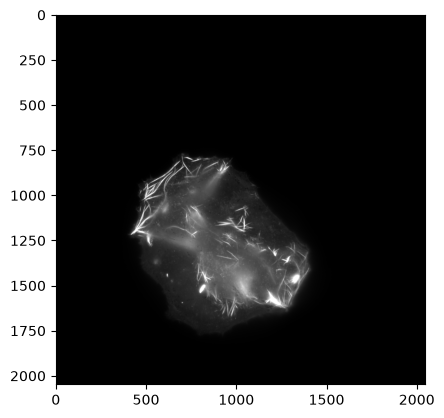

In [20]:
plt.imshow(test_image1, cmap='gray')

In [32]:
test_image1 = io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im1.png", as_gray=True)

#all variables for quick access fine tuning and maybe later adding into UI for changing
BACK_GRND_RADIUS = 12 # disk size for tophat
SIGMAS = range(1,4)   # for edge detection filter
RIDGE_K = 3           # multiplier constant for ridge mask tuning
BRIGHTNESS_K = 5      # multiplier constant for brightness mask tuning
SML_OBJ_PIX = 8      # for removing small objects (size of smalles object)

def clean(image):     
    """Function for cleaning image using two masks and finding where they overlap,
    Creates cleaned binary mask of image for further processing"""

    #converting images to usable format
    if image.ndim == 3:
        image.color.rgb2gray(image[..., :3])
    image = util.img_as_float(image)

    #gausian filter for img smoothing
    image_gaus = filters.gaussian(image, sigma=1)

    #background subtraction
    tophat = morphology.white_tophat(image_gaus, morphology.disk(BACK_GRND_RADIUS))

    #background detection
    ridges = filters.sato(tophat,sigmas=SIGMAS, black_ridges=False)

    #formula for following masks
    #Threshold = mean + (stdev * k)   (k is the Z score, or number of stdevs away from the mean)
    #So it only takes the top percent of the 

    #ridge mask for finding ridges 
    ridge_mask = ridges > (ridges.mean() + RIDGE_K * ridges.std())

    #brightness mask for finding brightness
    brightness_mask = tophat > (tophat.mean() + BRIGHTNESS_K * tophat.std())


    #creates a mask that takes from both the masks above if they are present in BOTH masks
    #this finds objects that have ridges and are also exceptionally bright
    binary_image = brightness_mask & ridge_mask
    #removing small defects
    binary_image = morphology.remove_small_objects(binary_image, max_size=SML_OBJ_PIX)
    return binary_image


In [33]:
cleaned_im2 = clean(io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im2.png",as_gray=True))

Text(0.5, 1.0, 'changed')

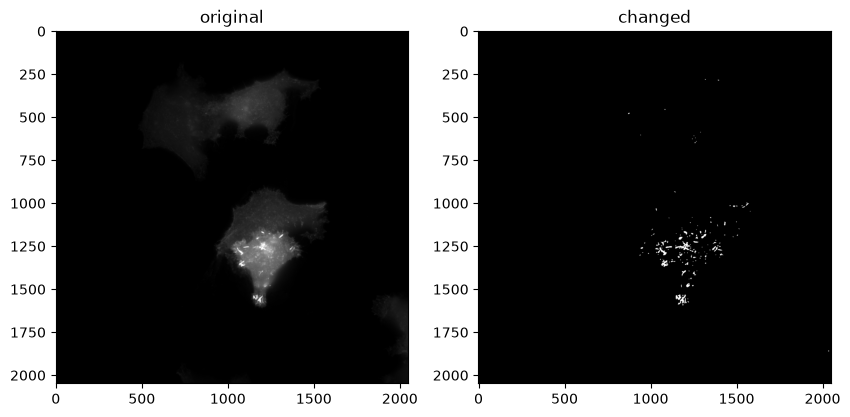

In [34]:
uncleaned_im2 = io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im2.png", as_gray=True)

fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(uncleaned_im2, cmap='gray')
axes[0].set_title("original")

axes[1].imshow(cleaned_im2, cmap='gray')
axes[1].set_title("changed")


Text(0.5, 1.0, 'changed')

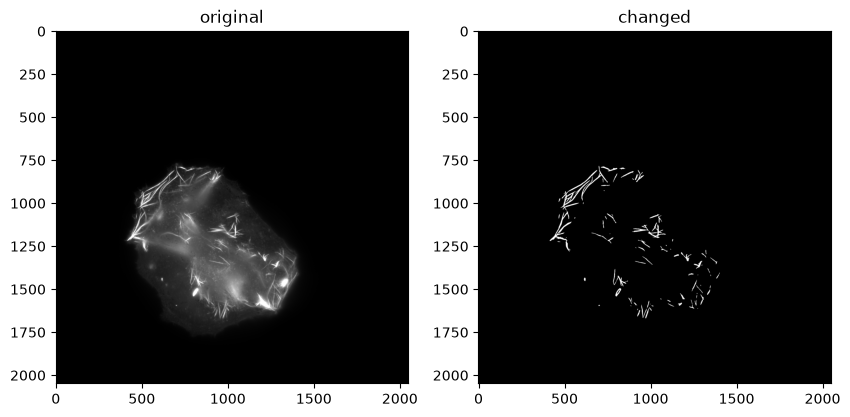

In [35]:
uncleaned_im1 = io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im1.png", as_gray=True)
cleaned_im1 = clean(io.imread("/Users/tylermoore/Main_Workspaces/Main/Cell_im_data/extracted/Test_im/Test_im1.png", as_gray=True))
fig, axes = plt.subplots(1,2, figsize=(10,5))

axes[0].imshow(uncleaned_im1, cmap='gray')
axes[0].set_title("original")

axes[1].imshow(cleaned_im1, cmap='gray')
axes[1].set_title("changed")